# Assignment 15: Light GBM and XG Boost algorithms using the Titanic dataset
##### Author: Md Ashhar Farooqui
##### Date: 22-07-2025

## Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, and lightgbm.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import xgboost as xgb
import lightgbm as lgb

## Load the Titanic Dataset
Load the Titanic dataset using pandas. Display the first few rows.

In [20]:
# Load the Titanic dataset
df = pd.read_csv('Titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing
Handle missing values, encode categorical variables, and perform any necessary data cleaning.

In [21]:
# Check for missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

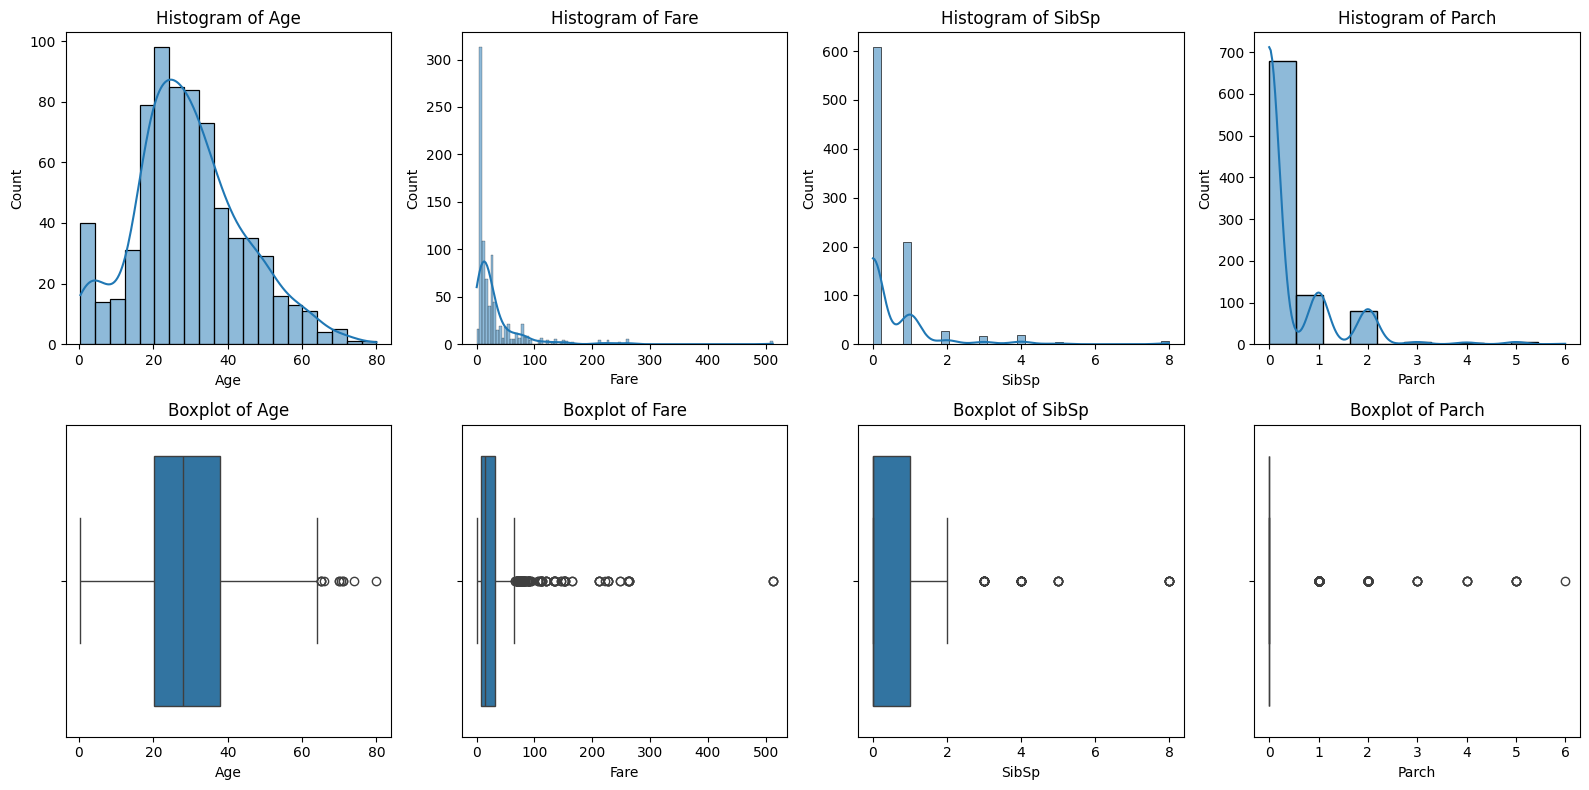

In [22]:
# Explore data distributions using histograms and box plots
num_features = ['Age', 'Fare', 'SibSp', 'Parch']
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_features):
    plt.subplot(2, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.subplot(2, 4, i+5)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

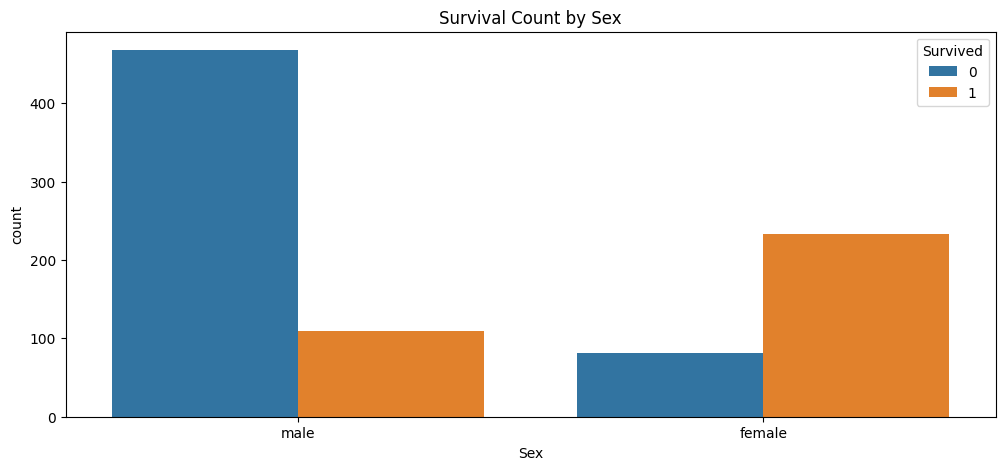

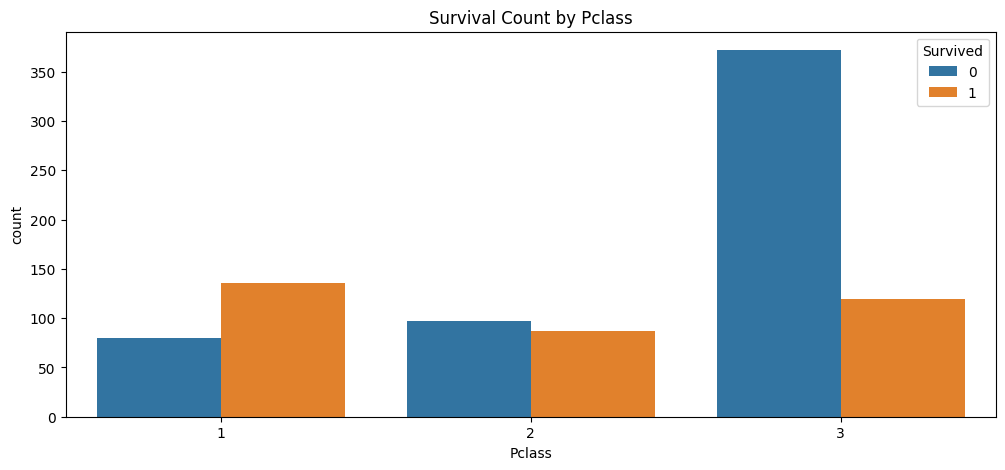

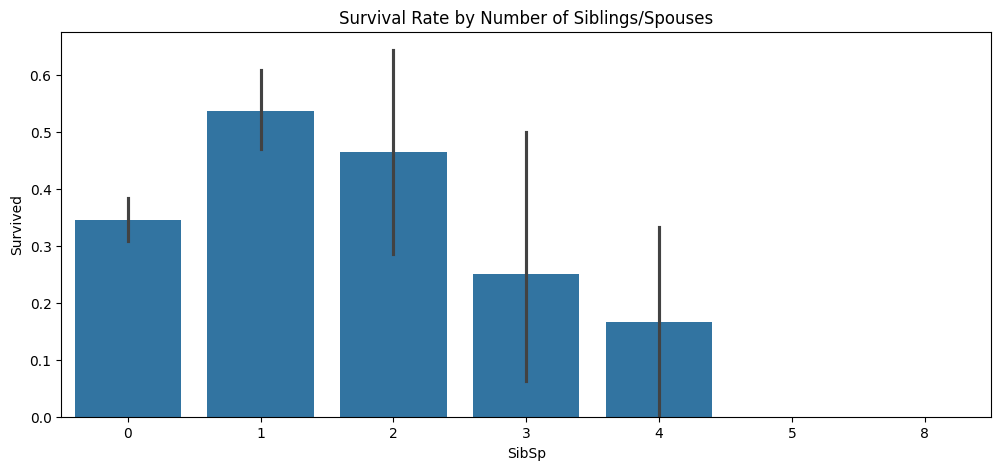

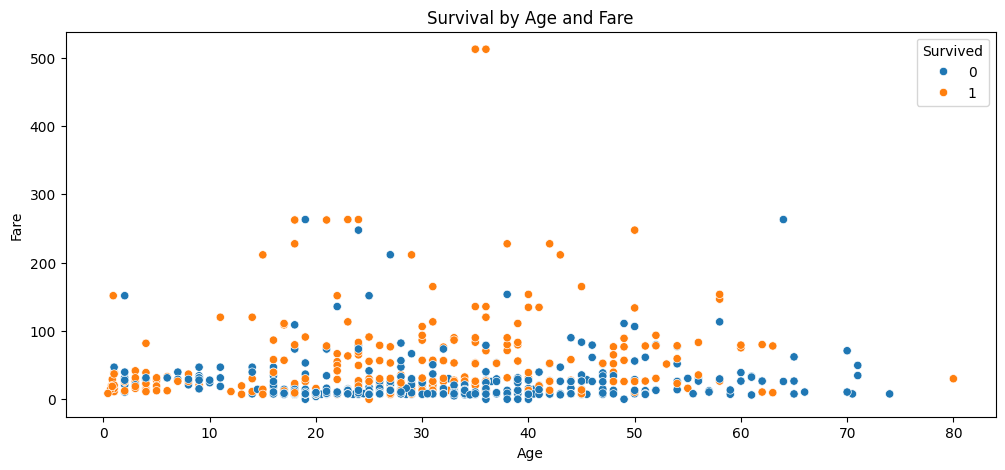

In [23]:
# Visualize relationships between features and survival
plt.figure(figsize=(12, 5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Pclass')
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(x='SibSp', y='Survived', data=df)
plt.title('Survival Rate by Number of Siblings/Spouses')
plt.show()

plt.figure(figsize=(12, 5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Survival by Age and Fare')
plt.show()

In [24]:
# Fill missing 'Age' values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing 'Embarked' values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' due to too many missing values
df.drop('Cabin', axis=1, inplace=True)

C:\Users\Ashhar\AppData\Local\Temp\ipykernel_11812\3297222817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Ashhar\AppData\Local\Temp\ipykernel_11812\3297222817.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [25]:
# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

## Feature Engineering
Create new features or transform existing ones to improve model performance.

In [26]:
# Create a new feature: FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Drop unnecessary columns
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

## Split Data into Train and Test Sets
Use train_test_split from scikit-learn to split the data into training and testing sets.

In [27]:
# Define features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Train XGBoost Classifier
Train an XGBoost classifier on the training data.

In [28]:
# Cross-validation and hyperparameter tuning for XGBoost
from sklearn.model_selection import GridSearchCV

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best XGBoost CV Accuracy:", xgb_grid.best_score_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best XGBoost CV Accuracy: 0.8273712203289667


c:\py-3.13.3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:30:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluate XGBoost Model
Evaluate the XGBoost model using accuracy, confusion matrix, and classification report.

In [29]:
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8100558659217877
Confusion Matrix:
 [[94 16]
 [18 51]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Train LightGBM Classifier
Train a LightGBM classifier on the training data.

In [30]:
# Cross-validation and hyperparameter tuning for LightGBM
lgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, -1],
    'learning_rate': [0.01, 0.1, 0.2]
}

lgb_grid = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42),
    param_grid=lgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
lgb_grid.fit(X_train, y_train)
print("Best LightGBM Params:", lgb_grid.best_params_)
print("Best LightGBM CV Accuracy:", lgb_grid.best_score_)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


## Evaluate LightGBM Model
Evaluate the LightGBM model using accuracy, confusion matrix, and classification report.

In [31]:
y_pred_lgb = lgb_clf.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test, y_pred_lgb))

LightGBM Accuracy: 0.7877094972067039
Confusion Matrix:
 [[92 18]
 [20 49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



## Compare Model Performance
Compare the performance metrics of XGBoost and LightGBM models.

In [32]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ]
})

results

,Model,Accuracy
0,XGBoost,0.810056
1,LightGBM,0.787709
